In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from astropy.io import fits
from astropy.table import Table

In [2]:
# Set plotting parameters
import matplotlib as mpl
mpl.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 20,
    'axes.labelsize': 18,
    'xtick.labelsize': 16,
    'ytick.labelsize': 16,
    'legend.fontsize': 16,
    'font.family': 'sans-serif',
    'font.sans-serif': ['DejaVu Sans'],
    'axes.linewidth': 1.0,
    # Turn grid on by default
    'axes.grid': True,
    'grid.alpha': 0.3
})

## Plot Phi1 vs VRAD

In [3]:
desi_table='/pscratch/sd/p/pratsosa/rvpix-loa.fits'
DESIT = Table().read(desi_table, "RVTAB", mask_invalid=False)
DESITG = Table().read(desi_table, "GAIA", mask_invalid=False)
DESIT["source_id"] = DESITG["SOURCE_ID"]
del DESITG

In [4]:
df = pd.read_csv('/pscratch/sd/p/pratsosa/GD1_CATHODE_mlp/results_MLP_512HU_5HL_50drop.csv')

In [5]:
df = df.drop_duplicates(subset='source_id').reset_index(drop=True)

source_ids = df['source_id'].astype(np.int64).values
print(len(np.unique(source_ids)) - len(source_ids))  # should be 0

0


In [6]:
src_col = DESIT['source_id']
src_col.mask.sum()

np.int64(2146247)

In [7]:
# get numpy array of ids (convert to int when safe)
DESIT_ids = np.array(DESIT['source_id'])
print("DESIT rows (after removing invalid):", len(DESIT_ids),
      "unique IDs:", len(np.unique(DESIT_ids)),
      "diff (unique - rows):", len(np.unique(DESIT_ids)) - len(DESIT_ids))

# Keep first occurrence of each source_id
uniq_vals, uniq_first_idx = np.unique(DESIT_ids, return_index=True)
keep_idx = np.sort(uniq_first_idx)          # maintain original order of first occurrences
DESIT_unique = DESIT[keep_idx]

# replace table and re-report
DESIT = DESIT_unique
DESIT_ids = np.array(DESIT['source_id']).astype(np.int64)
print("DESIT rows (after dedup):", len(DESIT_ids),
      "unique IDs:", len(np.unique(DESIT_ids)),
      "diff (unique - rows):", len(np.unique(DESIT_ids)) - len(DESIT_ids))
# ...existing code...

DESIT rows (after removing invalid): 15947824 unique IDs: 12480896 diff (unique - rows): -3466928
DESIT rows (after dedup): 12480896 unique IDs: 12480896 diff (unique - rows): 0


In [8]:
DESIT_ids = np.array(DESIT['source_id'])

In [9]:
# find the intersection of DESIT_ids and source_ids_uniq using np.intersect1d
common_ids, indices_DESIT, indices_source = np.intersect1d(DESIT_ids, source_ids, return_indices=True, assume_unique=True)
print(f"Number of common source_ids between DESIT and predictions: {len(common_ids)}")

Number of common source_ids between DESIT and predictions: 10138


In [10]:
# Keep only those rows in DESIT and df which have source_ids in common_ids
DESIT_common = DESIT[indices_DESIT]
df_common = df.iloc[indices_source].reset_index(drop=True)

In [11]:
# Reorder DESIT_common and df_common so they share the same source_id ordering.
# Reference ordering: DESIT_common (astropy Table). Reorder df_common (pandas) to match.

# get id arrays (normalize dtype)
desit_common_ids = np.array(DESIT_common['source_id']).astype(np.int64)
df_common_ids    = df_common['source_id'].astype(np.int64).values

# quick sanity: same set of IDs
if not np.array_equal(np.sort(desit_common_ids), np.sort(df_common_ids)):
    raise ValueError("DESIT_common and df_common do not contain the same source_ids")

# build index map for df_common and reorder to follow DESIT_common order
idx_map = {sid: i for i, sid in enumerate(df_common_ids)}
new_order = [idx_map[sid] for sid in desit_common_ids]

df_common = df_common.iloc[new_order].reset_index(drop=True)
# DESIT_common (astropy Table) is already in the reference order (desit_common_ids)
# If you want DESIT_common as a new variable (pandas) you can also convert:
# DESIT_common = DESIT_common[list(range(len(DESIT_common)))]  # no-op, kept for clarity

# verify alignment
assert np.array_equal(np.array(DESIT_common['source_id']).astype(np.int64), df_common['source_id'].astype(np.int64).values)
print("DESIT_common and df_common are now aligned by source_id.")

DESIT_common and df_common are now aligned by source_id.


In [12]:
np.array(df_common['true_label']).sum()

np.float64(91.0)

In [13]:
df_common.head()

,source_id,phi1,phi2,pm_phi1,pm_phi2,pmra_error,pmdec_error,bp_rp,gmag,rmag0,g_r,r_z,model_prob,true_label
0,5.764656e+17,-36.508755,-8.760049,-8.108584,-4.126551,0.268878,0.157249,0.828291,18.817284,18.675226,0.427288,0.134838,0.496972,0.0
1,5.764684e+17,-36.334099,-8.823325,-12.108052,8.235608,0.042188,0.027492,0.980023,14.600136,14.436377,0.552838,0.203154,0.496972,0.0
2,5.765127e+17,-35.712387,-9.013329,-10.071270,-0.692537,0.153422,0.105012,0.747135,17.870394,17.730659,0.346191,0.083910,0.496972,0.0
3,5.765197e+17,-35.969288,-8.696044,-8.477757,-15.671000,0.125792,0.081887,0.690105,17.610048,17.502937,0.291918,0.051033,0.496972,0.0
4,5.765452e+17,-36.147438,-8.401954,-8.860891,-7.725535,0.283419,0.169547,0.890558,19.014044,18.876249,0.395885,0.105150,0.496972,0.0


In [14]:
phi1 = np.array(df_common['phi1'])
vrad = np.array(DESIT_common['VRAD'])

In [15]:
probs = np.array(df_common['model_prob'])
preds = (np.array(df_common['model_prob']) >= 0.7586).astype(bool)
labels = np.array(df_common['true_label']).astype(bool)

In [16]:
mask_thresh = (probs >= 0.497)
probs_thresh = probs[mask_thresh]
preds_thresh = preds[mask_thresh]

In [17]:
tp = (labels & preds)
fp = (~labels & preds)
fn = (labels & ~preds)

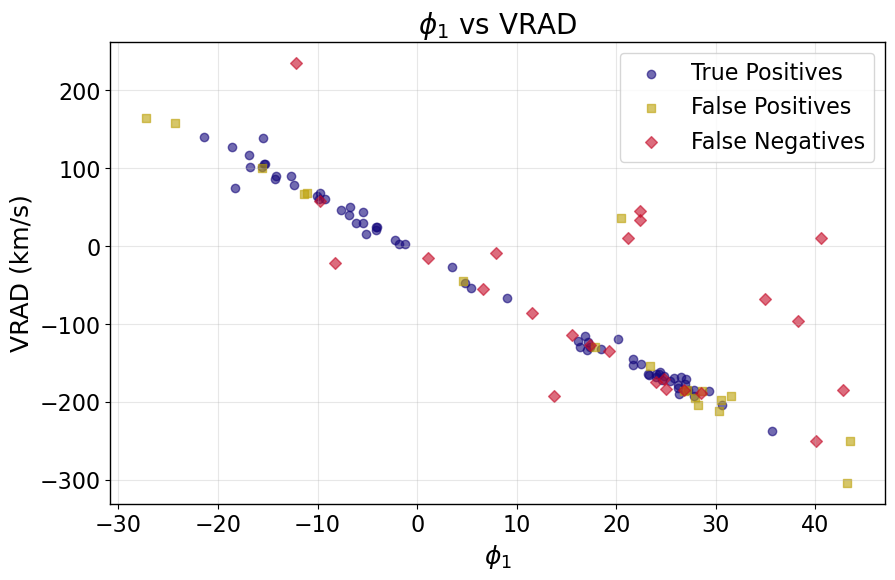

In [18]:
# Plot phi1 vs vrad, color-coded by TP, FP, FN
colors = ["#15097C", "#bca006","#c50b27"]
markers = ['o', 's', 'D']
plt.figure(figsize=(10, 6))
plt.scatter(phi1[tp], vrad[tp], label='True Positives', alpha=0.6, color = colors[0], marker=markers[0])
plt.scatter(phi1[fp], vrad[fp], label='False Positives', alpha=0.6, color = colors[1], marker=markers[1])
plt.scatter(phi1[fn], vrad[fn], label='False Negatives', alpha=0.6, color = colors[2], marker=markers[2])
plt.xlabel('$\\phi_1$')
plt.ylabel('VRAD (km/s)')
plt.title('$\\phi_1$ vs VRAD')
plt.legend()
plt.savefig('GD1_Plots//phi1_vrad_TP_FP_FN.png', dpi=300)
plt.show()


Text(0.5, 1.0, '$\\phi_1$ vs VRAD colored by Model Probability')

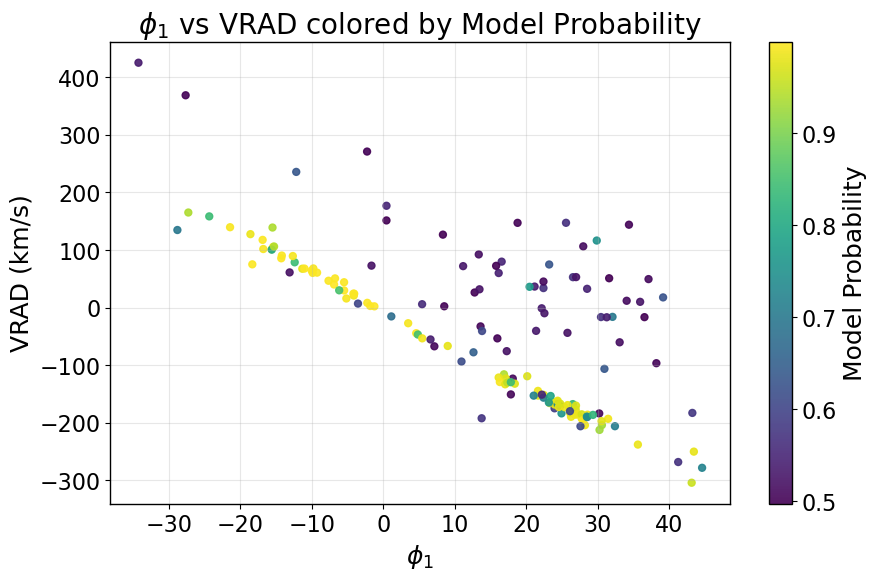

In [19]:
# I want to plot the stars in phi1 and vrad space, color-coded by their model probabilities
plt.figure(figsize=(10, 6))
sc = plt.scatter(phi1[mask_thresh], vrad[mask_thresh], c=probs_thresh, cmap='viridis', alpha=0.9, s=25)
plt.colorbar(sc, label='Model Probability')
plt.xlabel('$\\phi_1$')
plt.ylabel('VRAD (km/s)')
plt.title('$\\phi_1$ vs VRAD colored by Model Probability')
# plt.savefig('GD1_Plots//phi1_vrad_model_prob.png', dpi=300)

## Separate Analysis using Emma's high quality labels

In [42]:
desi = '/pscratch/sd/p/pratsosa/GD1_DESI_memprob.fits'
desi_table = Table.read(desi)

In [43]:
path = '/pscratch/sd/p/pratsosa/GD1_Gaia_HighPurity.fits'

with fits.open(path, memmap=False) as hdul:
    hdu = hdul[1]  # your BinTableHDU

    # build sanitized ColDefs (safe string names for every column)
    safe_cols = []
    seen = set()
    for i, col in enumerate(hdu.columns):
        name = col.name
        # normalize bytes/None -> string
        sname = name.decode('ascii', errors='ignore').strip() if isinstance(name, bytes) else str(name).strip()
        if not sname or sname.lower() == 'none':
            sname = f'col{i}'
        orig = sname; j = 1
        while sname in seen:
            sname = f"{orig}_{j}"; j += 1
        seen.add(sname)

        # keep the original FITS format and metadata
        safe_cols.append(fits.Column(name=sname, format=col.format, unit=col.unit,
                                     null=getattr(col, 'null', None),
                                     bscale=getattr(col, 'bscale', None),
                                     bzero=getattr(col, 'bzero', None)))

    safe_coldefs = fits.ColDefs(safe_cols)

    # construct numpy dtype from safe_coldefs (no error because names are strings)
    dtype = safe_coldefs.dtype

    # read raw table bytes with the safe dtype (avoids calling hdu.data)
    raw = hdu._get_raw_data(hdu._nrows, dtype, hdu._data_offset)

    # view as record array and build an Astropy Table excluding the first column
    rec = raw.view(np.recarray)
    safe_names = list(safe_coldefs.names)
    keep = safe_names[1:]  # drop the first problematic column
    data_dict = {name: rec[name] for name in keep}
    high_prob_table = Table(data_dict)

print("Loaded table with columns:", high_prob_table.colnames)

Loaded table with columns: ['ebv', 'ra', 'dec', 'flux_g', 'flux_r', 'flux_z', 'flux_w1', 'flux_ivar_w1', 'startyp', 'maskbits', 'anymask_g', 'anymask_r', 'anymask_z', 'allmask_g', 'allmask_r', 'allmask_z', 'gdist', 'ruwe', 'pmra', 'pmdec', 'pmra_error', 'pmdec_error', 'parallax', 'parallax_error', 'phot_g_mean_mag', 'phot_bp_mean_mag', 'phot_rp_mean_mag', 'source_id', 'pseudocolour', 'ecl_lat', 'astrometric_params_solved', 'nu_eff_used_in_astrometry', 'g', 'r', 'z', 'phi1', 'phi2', 'pmphi1', 'pmphi2']


In [44]:
# find the intersection of DESIT_ids and source_ids_uniq using np.intersect1d
high_prob_ids = np.array(high_prob_table['source_id']).astype(np.int)
common_ids, indices_high_prob, indices_source = np.intersect1d(high_prob_ids, source_ids, return_indices=True, assume_unique=True)
print(f"Number of common source_ids: {len(common_ids)}")

AttributeError: module 'numpy' has no attribute 'int'.
`np.int` was a deprecated alias for the builtin `int`. To avoid this error in existing code, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional information.
The aliases was originally deprecated in NumPy 1.20; for more details and guidance see the original release note at:
    https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations

In [56]:
desi_ids = np.array(desi_table['source_id']).astype(np.int64)
common_ids_desi, indices_desi, indices_source_desi = np.intersect1d(desi_ids, source_ids, return_indices=True, assume_unique=False)
print(f"Number of common source_ids with DESI table: {len(common_ids_desi)}")

Number of common source_ids with DESI table: 97


In [57]:
desi_common = desi_table[indices_desi]
df_desi_common = df.iloc[indices_source_desi].reset_index(drop=True)

In [58]:
desi_common_ids = np.array(desi_common['source_id']).astype(np.int64)
df_desi_common_ids    = np.array(df_desi_common['source_id']).astype(np.int64)

# quick sanity: same set of IDs
if not np.array_equal(np.sort(desi_common_ids), np.sort(df_desi_common_ids)):
    raise ValueError("desi_common and df_desi_common do not contain the same source_ids")

# build index map for df_common and reorder to follow DESIT_common order
idx_map = {sid: i for i, sid in enumerate(df_desi_common_ids)}
new_order = [idx_map[sid] for sid in desi_common_ids]

df_desi_common = df_desi_common.iloc[new_order].reset_index(drop=True)
# DESIT_common (astropy Table) is already in the reference order (desit_common_ids)
# If you want DESIT_common as a new variable (pandas) you can also convert:
# DESIT_common = DESIT_common[list(range(len(DESIT_common)))]  # no-op, kept for clarity

# verify alignment
assert np.array_equal(np.array(desi_common['source_id']).astype(np.int64), df_desi_common['source_id'].astype(np.int64).values)
print("desi_common and df_desi_common are now aligned by source_id.")

desi_common and df_desi_common are now aligned by source_id.


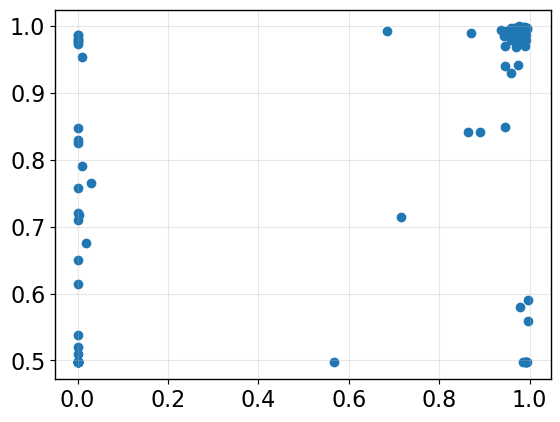

In [60]:
plt.scatter(desi_common['p_stream'], df_desi_common['model_prob'])

In [61]:
desi_preds = (np.array(df_desi_common['model_prob']) > 0.7586)
desi_labels = np.array(desi_common['p_stream'] > 0.5)